In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [90]:
# Cargar la base de datos
data = pd.read_csv('recursos_humanos.csv')
data

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [89]:
# Re-codificar las variables categóricas
encoded_data = pd.get_dummies(data, columns=['sales', 'salary'], dtype=int)
encoded_data

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales_IT,sales_RandD,...,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_high,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,0.80,0.86,5,262,6,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0.11,0.88,7,272,4,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,0.72,0.87,5,223,5,0,1,0,0,0,...,0,0,0,0,1,0,0,0,1,0
4,0.37,0.52,2,159,3,0,1,0,0,0,...,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,0,0,...,0,0,0,0,0,1,0,0,1,0
14995,0.37,0.48,2,160,3,0,1,0,0,0,...,0,0,0,0,0,1,0,0,1,0
14996,0.37,0.53,2,143,3,0,1,0,0,0,...,0,0,0,0,0,1,0,0,1,0
14997,0.11,0.96,6,280,4,0,1,0,0,0,...,0,0,0,0,0,1,0,0,1,0


In [151]:
# Análisis exploratorio de datos(EDA)
encoded_data.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales_IT,sales_RandD,...,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_high,salary_low,salary_medium
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,...,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268,0.081805,0.052470,...,0.049270,0.042003,0.057204,0.060137,0.276018,0.148610,0.181345,0.082472,0.487766,0.429762
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281,0.274077,0.222981,...,0.216438,0.200602,0.232239,0.237749,0.447041,0.355715,0.385317,0.275092,0.499867,0.495059
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<Figure size 640x480 with 0 Axes>

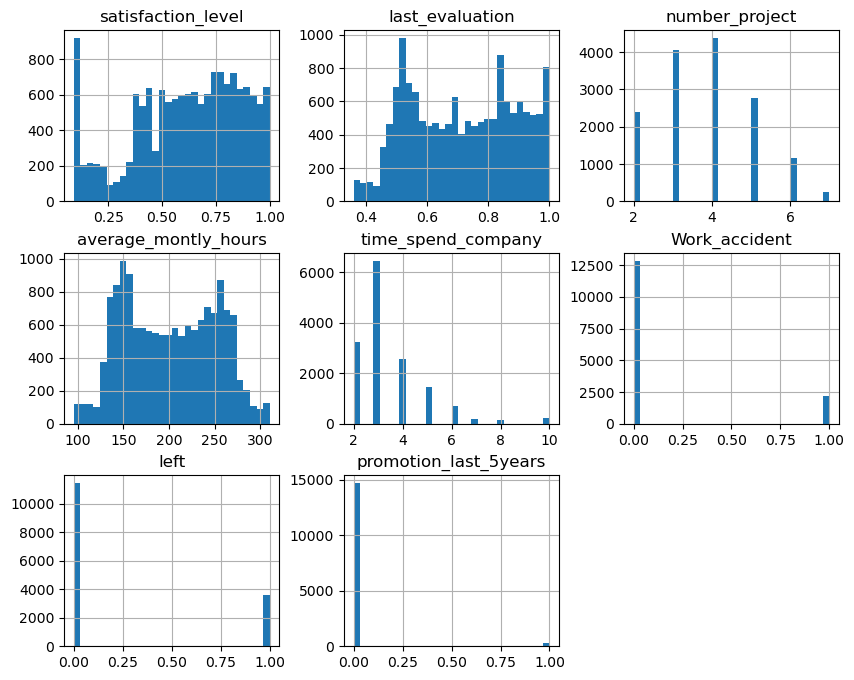

In [140]:
plt.figure()
data.hist(bins=30, figsize=(10, 8))
plt.savefig('EDA_tarea21.png')
plt.show()

In [24]:
y = encoded_data.left.values
x_data = encoded_data.drop(['left'], axis=1)

In [146]:
# Normalización
x = (x_data - x_data.min()) / (x_data.max() - x_data.min())

In [147]:
# Bases de entrenamiento y prueba
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [148]:
# Modelo KNN
from sklearn.neighbors import KNeighborsClassifier
s=[]
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)
    prediction = knn.predict(x_test)
    score = knn.score(x_test, y_test)
    s.append(score)

In [149]:
# Tabla de comparación de las diversas precisiones
k = np.linspace(1, 20, 20)
d = {'k':k, 'score':s}
df = pd.DataFrame(d)
df

,k,score
0,1.0,0.960000
1,2.0,0.952889
2,3.0,0.937556
3,4.0,0.938667
4,5.0,0.932889
5,6.0,0.939333
6,7.0,0.933111
7,8.0,0.936667
8,9.0,0.932000
9,10.0,0.933778


In [150]:
# k óptima
k_optima = df.loc[df['score'].idxmax(), 'k']
k_optima

np.float64(1.0)

In [84]:
# Modelo KNN con k óptima
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(x_train, y_train)
prediction = knn.predict(x_test)

In [85]:
y_pred = prediction
y_true = y_test

In [86]:
# Matriz de confusión
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)
cm

array([[3309,  119],
       [  61, 1011]])

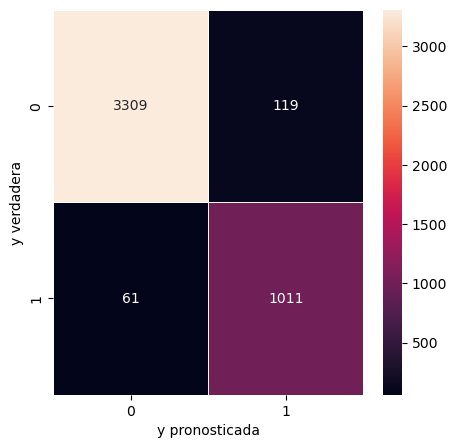

In [144]:
# Visualización matriz de confusión(mapa de calor)
import seaborn as sns
f, ax = plt.subplots(figsize=(5,5))
sns.heatmap(cm, annot=True, linewidths=0.5, color='red', fmt='.0f', ax=ax)
plt.xlabel('y pronosticada')
plt.ylabel('y verdadera')
plt.show()

In [145]:
f.savefig('heatmap_tarea21.png')

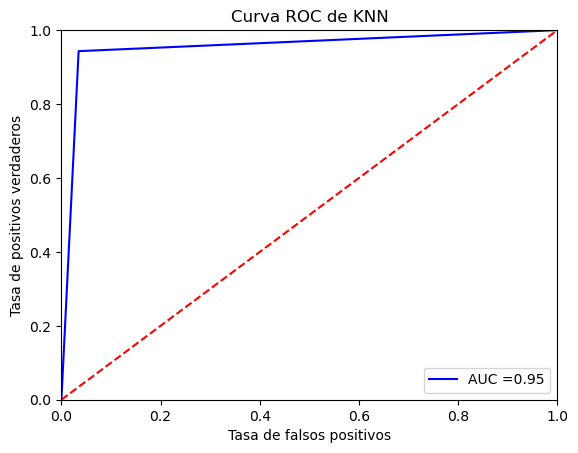

In [143]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

y_scores = knn.predict_proba(x_test)

fpr, tpr, threshold = roc_curve(y_test, y_scores[:,1])
# fpr = false positive rate
# tpr = true positive rate 
roc_auc = auc(fpr, tpr)

plt.figure()
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label='AUC =%0.2f' %roc_auc)
plt.legend(loc='lower right')
plt.plot([0,1], [0,1], 'r--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel('Tasa de positivos verdaderos')
plt.xlabel('Tasa de falsos positivos')
plt.title('Curva ROC de KNN')
plt.savefig('CurvaROC_tarea21.png')
plt.show()